In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install librosa soundfile numpy scipy pandas scikit-learn webrtcvad praat-parselmouth matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 70.0 MB/s eta 0:00:00
  Created wheel for webrtcvad: filename=webrtcvad-2.0.10-cp312-cp312-linux_x86_64.whl size=73522 sha256=097cf0a6012a171caaa7583cc5e9f0c11da6cb7a7fde93fb0bea1a0db0a24378
  Stored in directory: /root/.cache/pip/wheels/1e/d3/95/680fa3b16848f1a58d2edaed34c496224c89a9bc63e17b3614
Successfully built webrtcvad


In [3]:
control_dir  = "/content/drive/MyDrive/UASpeech_noisereduce_C/UASpeech/audio/noisereduce/"
FM_dir = "/content/drive/MyDrive/UASpeech_noisereduce_FM/UASpeech/audio/noisereduce/"


In [4]:
# control_dir = "/content/drive/MyDrive/UASpeech_noisereduce_C/UASpeech/audio/noisereduce/"
# FM_dir = "/content/drive/MyDrive/UASpeech_noisereduce_FM/UASpeech/audio/noisereduce/"

# config = PipelineConfig(
#     target_sr=16000,
#     selected_mic="M2",
#     silero_thresholds=(0.7, 0.8, 0.9),
#     n_splits=5,
#     output_dir="outputs_uaspeech_silero_antivad",
# )

# results = run_focused_uaspeech_experiment(
#     control_dir=control_dir,
#     fm_dir=FM_dir,
#     config=config,
#     include_unknown_severity=False,
#     run_vad_example_export=True,
# )

In [5]:
# """
# Focused Privacy-Aware Dysarthria Assessment Pipeline
# UA-Speech + Silero Anti-VAD + Speaker-Independent Evaluation

# Main questions:
# 1. What accuracy do we get with and without privacy filtering?
# 2. Which subsystem features are most important?
# 3. Which subsystem features matter for each severity?

# Representations:
# - raw
# - silero_antivad_0.7
# - silero_antivad_0.8
# - silero_antivad_0.9
# """

# # =============================================================================
# # Imports
# # =============================================================================

# import os
# import glob
# import json
# import warnings
# from dataclasses import dataclass
# from typing import Dict, Any, List, Tuple

# import numpy as np
# import pandas as pd
# import librosa
# import soundfile as sf

# from sklearn.model_selection import GroupKFold
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import (
#     accuracy_score,
#     balanced_accuracy_score,
#     confusion_matrix,
#     f1_score,
# )

# from sklearn.ensemble import RandomForestClassifier
# from sklearn.inspection import permutation_importance

# import torch

# try:
#     import parselmouth
#     PRAAT_AVAILABLE = True
# except:
#     PRAAT_AVAILABLE = False


# IGNORE_FOLDERS = {
#     "Anti Silero 0.8",
#     "logmel_128",
#     "log_mel",
#     "logmel",
#     "mel",
#     "logs",
# }


# # =============================================================================
# # Config
# # =============================================================================

# @dataclass
# class PipelineConfig:
#     target_sr: int = 16000
#     selected_mic: str = "M2"
#     random_state: int = 42
#     n_splits: int = 5
#     output_dir: str = "outputs_uaspeech_silero_antivad"

#     silero_thresholds: Tuple[float, ...] = (0.7, 0.8, 0.9)

#     n_mfcc: int = 13
#     frame_length_ms: int = 25
#     hop_length_ms: int = 10


# # =============================================================================
# # Labels
# # =============================================================================

# DYSARTHRIC_SPEAKER_INFO = {
#     "M01": "very_low",
#     "M04": "very_low",
#     "M05": "medium",
#     "M06": "low",
#     "M07": "low",
#     "M08": "high",
#     "M09": "high",
#     "M10": "high",
#     "F02": "low",
#     "F03": "very_low",
#     "F04": "medium",
#     "F05": "high",
#     "M11": "medium",
#     "M12": "very_low",
#     "M14": "high",
#     "M16": "low",
# }

# CLASS_ORDER = ["control", "high", "medium", "low", "very_low"]


# # =============================================================================
# # Utils
# # =============================================================================

# def ensure_dir(path):
#     os.makedirs(path, exist_ok=True)


# def safe_divide(a, b):
#     return a / b if b != 0 else 0.0


# def summarize_array(x, prefix):

#     x = np.asarray(x)
#     x = x[np.isfinite(x)]

#     if len(x) == 0:
#         return {
#             f"{prefix}_mean": 0,
#             f"{prefix}_std": 0,
#             f"{prefix}_min": 0,
#             f"{prefix}_max": 0,
#         }

#     return {
#         f"{prefix}_mean": float(np.mean(x)),
#         f"{prefix}_std": float(np.std(x)),
#         f"{prefix}_min": float(np.min(x)),
#         f"{prefix}_max": float(np.max(x)),
#     }


# # =============================================================================
# # Parse dataset
# # =============================================================================

# def keep_selected_mic_only(wav_files, selected_mic="M2"):

#     return [
#         f for f in wav_files
#         if f"_{selected_mic}.wav" in f
#     ]


# def parse_uaspeech_dataset(
#     control_dir,
#     fm_dir,
#     config,
# ):

#     rows = []

#     # ----------------------------
#     # controls
#     # ----------------------------

#     control_speakers = sorted(os.listdir(control_dir))

#     print (control_speakers)

#     for speaker_id in control_speakers:

#         if speaker_id in IGNORE_FOLDERS:
#           continue

#         speaker_dir = os.path.join(control_dir, speaker_id)

#         if not os.path.isdir(speaker_dir):
#             continue

#         wav_files = glob.glob(os.path.join(speaker_dir, "*.wav"))
#         print (len(wav_files))
#         wav_files = keep_selected_mic_only(
#             wav_files,
#             selected_mic=config.selected_mic
#         )
#         print (len(wav_files))

#         wav_files = wav_files[:10]

#         for wav_path in wav_files:

#             rows.append({
#                 "audio_path": wav_path,
#                 "speaker_id": speaker_id,
#                 "label": "control",
#             })

#     # ----------------------------
#     # dysarthric
#     # ----------------------------

#     dys_speakers = sorted(os.listdir(fm_dir))
#     print (dys_speakers)

#     for speaker_id in dys_speakers:
#         if speaker_id in IGNORE_FOLDERS:
#           continue

#         speaker_dir = os.path.join(fm_dir, speaker_id)

#         if not os.path.isdir(speaker_dir):
#             continue

#         if speaker_id not in DYSARTHRIC_SPEAKER_INFO:
#             continue

#         label = DYSARTHRIC_SPEAKER_INFO[speaker_id]

#         wav_files = glob.glob(os.path.join(speaker_dir, "*.wav"))
#         print (len(wav_files))
#         wav_files = keep_selected_mic_only(
#             wav_files,
#             selected_mic=config.selected_mic
#         )
#         print (len(wav_files))
#         wav_files = wav_files[:10]

#         for wav_path in wav_files:

#             rows.append({
#                 "audio_path": wav_path,
#                 "speaker_id": speaker_id,
#                 "label": label,
#             })

#     return pd.DataFrame(rows)


# # =============================================================================
# # Audio loading
# # =============================================================================

# def load_audio(audio_path, config):

#     y, sr = librosa.load(
#         audio_path,
#         sr=config.target_sr,
#         mono=True
#     )

#     y = y / (np.max(np.abs(y)) + 1e-8)

#     return y.astype(np.float32), sr


# # =============================================================================
# # Silero AntiVAD
# # =============================================================================

# silero_model, silero_utils = torch.hub.load(
#     repo_or_dir='snakers4/silero-vad',
#     model='silero_vad',
#     force_reload=False
# )

# get_speech_timestamps = silero_utils[0]


# def silero_antivad_filter(y, sr, threshold=0.8):

#     speech_timestamps = get_speech_timestamps(
#         torch.from_numpy(y),
#         silero_model,
#         sampling_rate=sr,
#         threshold=threshold
#     )

#     mask = np.zeros(len(y), dtype=bool)

#     for seg in speech_timestamps:

#         start = seg["start"]
#         end = seg["end"]

#         mask[start:end] = True

#     y_private = y.copy()

#     # remove speech
#     y_private[mask] = 0

#     return y_private.astype(np.float32)


# def create_representation(y, sr, representation):

#     if representation == "raw":
#         return y

#     if representation.startswith("silero_antivad_"):

#         threshold = float(representation.split("_")[-1])

#         return silero_antivad_filter(
#             y,
#             sr,
#             threshold=threshold
#         )

#     raise ValueError


# def get_representations(config):

#     reps = ["raw"]

#     for thr in config.silero_thresholds:
#         reps.append(f"silero_antivad_{thr}")

#     return reps


# # =============================================================================
# # Save VAD examples
# # =============================================================================

# def save_vad_examples(metadata, config):

#     out_dir = os.path.join(
#         config.output_dir,
#         "vad_examples"
#     )

#     ensure_dir(out_dir)

#     sampled = (
#         metadata.groupby("label")
#         .head(2)
#     )

#     for _, row in sampled.iterrows():

#         y, sr = load_audio(
#             row["audio_path"],
#             config
#         )

#         base = os.path.splitext(
#             os.path.basename(row["audio_path"])
#         )[0]

#         class_dir = os.path.join(
#             out_dir,
#             row["label"]
#         )

#         ensure_dir(class_dir)

#         sf.write(
#             os.path.join(class_dir, f"{base}_raw.wav"),
#             y,
#             sr
#         )

#         for thr in config.silero_thresholds:

#             y_private = silero_antivad_filter(
#                 y,
#                 sr,
#                 threshold=thr
#             )

#             sf.write(
#                 os.path.join(
#                     class_dir,
#                     f"{base}_silero_{thr}.wav"
#                 ),
#                 y_private,
#                 sr
#             )


# # =============================================================================
# # Feature extraction
# # =============================================================================

# def extract_respiration_features(y, sr):

#     rms = librosa.feature.rms(y=y)[0]

#     threshold = np.percentile(rms, 30)

#     active = rms > threshold

#     total_active = np.sum(active)
#     total_pause = len(active) - total_active

#     return {
#         "resp_pause_fraction":
#             safe_divide(total_pause, len(active)),

#         "resp_speech_pause_ratio":
#             safe_divide(total_active, total_pause),

#         **summarize_array(rms, "resp_rms")
#     }


# def extract_phonation_features(y, sr):

#     feats = {}

#     try:

#         f0, _, _ = librosa.pyin(
#             y,
#             sr=sr,
#             fmin=librosa.note_to_hz("C2"),
#             fmax=librosa.note_to_hz("C7")
#         )

#         f0_clean = f0[np.isfinite(f0)]

#     except:
#         f0_clean = np.array([])

#     feats.update(
#         summarize_array(f0_clean, "phon_f0")
#     )

#     if PRAAT_AVAILABLE:

#         try:

#             snd = parselmouth.Sound(y, sr)

#             pp = parselmouth.praat.call(
#                 snd,
#                 "To PointProcess (periodic, cc)",
#                 75,
#                 500
#             )

#             jitter = parselmouth.praat.call(
#                 pp,
#                 "Get jitter (local)",
#                 0,
#                 0,
#                 0.0001,
#                 0.02,
#                 1.3
#             )

#             feats["phon_jitter"] = float(jitter)

#         except:
#             feats["phon_jitter"] = 0

#     return feats


# def extract_articulation_features(y, sr, config):

#     mfcc = librosa.feature.mfcc(
#         y=y,
#         sr=sr,
#         n_mfcc=config.n_mfcc
#     )

#     delta = librosa.feature.delta(mfcc)

#     feats = {}

#     for i in range(config.n_mfcc):

#         feats.update(
#             summarize_array(
#                 mfcc[i],
#                 f"mfcc_{i+1}"
#             )
#         )

#         feats.update(
#             summarize_array(
#                 delta[i],
#                 f"delta_mfcc_{i+1}"
#             )
#         )

#     centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]

#     feats.update(
#         summarize_array(
#             centroid,
#             "spectral_centroid"
#         )
#     )

#     return feats


# def extract_prosody_features(y, sr):

#     onset_env = librosa.onset.onset_strength(
#         y=y,
#         sr=sr
#     )

#     tempo = librosa.feature.tempo(
#         onset_envelope=onset_env,
#         sr=sr
#     )[0]

#     return {
#         "pros_tempo": float(tempo),

#         **summarize_array(
#             onset_env,
#             "pros_onset"
#         )
#     }


# def extract_fluency_features(y, sr):

#     onset_frames = librosa.onset.onset_detect(
#         y=y,
#         sr=sr
#     )

#     onset_times = librosa.frames_to_time(
#         onset_frames,
#         sr=sr
#     )

#     ioi = np.diff(onset_times)

#     return {
#         "fluency_onset_count":
#             len(onset_frames),

#         **summarize_array(
#             ioi,
#             "fluency_ioi"
#         )
#     }


# def extract_all_features(y, sr, config):

#     nested = {
#         "respiration":
#             extract_respiration_features(y, sr),

#         "phonation":
#             extract_phonation_features(y, sr),

#         "articulation":
#             extract_articulation_features(y, sr, config),

#         "prosody":
#             extract_prosody_features(y, sr),

#         "fluency":
#             extract_fluency_features(y, sr),
#     }

#     flat = {}

#     for subsystem, feats in nested.items():

#         for k, v in feats.items():

#             flat[f"{subsystem}__{k}"] = v

#     return flat


# # =============================================================================
# # Feature table
# # =============================================================================

# def build_feature_table(metadata, config):

#     rows = []

#     reps = get_representations(config)

#     for idx, row in metadata.iterrows():

#         print(f"[{idx+1}/{len(metadata)}] {row['audio_path']}")

#         try:

#             y, sr = load_audio(
#                 row["audio_path"],
#                 config
#             )

#             for rep in reps:

#                 y_rep = create_representation(
#                     y,
#                     sr,
#                     rep
#                 )

#                 feats = extract_all_features(
#                     y_rep,
#                     sr,
#                     config
#                 )

#                 out = {
#                     "audio_path":
#                         row["audio_path"],

#                     "speaker_id":
#                         row["speaker_id"],

#                     "label":
#                         row["label"],

#                     "representation":
#                         rep,
#                 }

#                 out.update(feats)

#                 rows.append(out)

#         except Exception as e:

#             warnings.warn(
#                 f"Failed on {row['audio_path']}: {e}"
#             )

#     return pd.DataFrame(rows)


# # =============================================================================
# # Speaker-independent evaluation
# # =============================================================================

# def get_feature_columns(df):

#     meta = {
#         "audio_path",
#         "speaker_id",
#         "label",
#         "representation"
#     }

#     return [c for c in df.columns if c not in meta]


# def make_classifier(config):

#     return Pipeline([
#         ("scaler", StandardScaler()),

#         ("classifier", RandomForestClassifier(
#             n_estimators=500,
#             random_state=config.random_state,
#             class_weight="balanced",
#             n_jobs=-1
#         ))
#     ])


# def speaker_vote(df, classes):

#     rows = []

#     for speaker_id, g in df.groupby("speaker_id"):

#         true_label = g["true_label"].iloc[0]

#         proba_cols = [f"proba_{c}" for c in classes]

#         mean_probs = g[proba_cols].mean().values

#         pred = classes[np.argmax(mean_probs)]

#         rows.append({
#             "speaker_id": speaker_id,
#             "true_label": true_label,
#             "pred_label": pred
#         })

#     return pd.DataFrame(rows)


# def evaluate_representation(
#     feature_df,
#     representation,
#     config
# ):

#     df = feature_df[
#         feature_df["representation"] == representation
#     ].copy()

#     feature_cols = get_feature_columns(df)

#     X = (
#         df[feature_cols]
#         .replace([np.inf, -np.inf], np.nan)
#         .fillna(0)
#     )

#     y = df["label"].values

#     groups = df["speaker_id"].values

#     le = LabelEncoder()

#     le.fit(CLASS_ORDER)

#     y_enc = le.transform(y)

#     classes = le.classes_.tolist()

#     gkf = GroupKFold(
#         n_splits=config.n_splits
#     )

#     utt_preds = []
#     spk_preds = []

#     models = []

#     for fold, (tr, te) in enumerate(
#         gkf.split(X, y_enc, groups)
#     ):

#         Xtr = X.iloc[tr]
#         Xte = X.iloc[te]

#         ytr = y_enc[tr]
#         yte = y_enc[te]

#         model = make_classifier(config)

#         model.fit(Xtr, ytr)

#         models.append(model)

#         pred = model.predict(Xte)

#         proba = model.predict_proba(Xte)

#         temp = df.iloc[te][[
#             "audio_path",
#             "speaker_id",
#             "label"
#         ]].copy()

#         temp = temp.rename(
#             columns={"label": "true_label"}
#         )

#         temp["pred_label"] = le.inverse_transform(pred)

#         for i, c in enumerate(classes):

#             temp[f"proba_{c}"] = proba[:, i]

#         utt_preds.append(temp)

#         spk_preds.append(
#             speaker_vote(temp, classes)
#         )

#     utt_df = pd.concat(utt_preds)

#     spk_df = pd.concat(spk_preds)

#     utt_true = utt_df["true_label"]
#     utt_pred = utt_df["pred_label"]

#     spk_true = spk_df["true_label"]
#     spk_pred = spk_df["pred_label"]

#     return {
#         "utterance_accuracy":
#             accuracy_score(utt_true, utt_pred),

#         "utterance_balanced_accuracy":
#             balanced_accuracy_score(utt_true, utt_pred),

#         "utterance_macro_f1":
#             f1_score(
#                 utt_true,
#                 utt_pred,
#                 average="macro"
#             ),

#         "speaker_accuracy":
#             accuracy_score(spk_true, spk_pred),

#         "speaker_balanced_accuracy":
#             balanced_accuracy_score(spk_true, spk_pred),

#         "speaker_macro_f1":
#             f1_score(
#                 spk_true,
#                 spk_pred,
#                 average="macro"
#             ),

#         "utterance_confusion_matrix":
#             confusion_matrix(
#                 utt_true,
#                 utt_pred,
#                 labels=classes
#             ),

#         "speaker_confusion_matrix":
#             confusion_matrix(
#                 spk_true,
#                 spk_pred,
#                 labels=classes
#             ),

#         "classes": classes,

#         "feature_cols": feature_cols,

#         "model": models[-1],

#         "Xte": Xte,

#         "yte": yte,
#     }


# # =============================================================================
# # Feature importance
# # =============================================================================

# def subsystem_name(feature):

#     return feature.split("__")[0]


# def compute_feature_importance(results):

#     model = results["model"]

#     Xte = results["Xte"]

#     yte = results["yte"]

#     feats = results["feature_cols"]

#     perm = permutation_importance(
#         model,
#         Xte,
#         yte,
#         n_repeats=10,
#         random_state=42,
#         n_jobs=-1
#     )

#     df = pd.DataFrame({
#         "feature": feats,
#         "importance": perm.importances_mean
#     })

#     df["subsystem"] = df["feature"].apply(
#         subsystem_name
#     )

#     df = df.sort_values(
#         "importance",
#         ascending=False
#     )

#     return df


# def compute_subsystem_importance(importance_df):

#     out = (
#         importance_df
#         .groupby("subsystem")["importance"]
#         .sum()
#         .reset_index()
#     )

#     out = out.sort_values(
#         "importance",
#         ascending=False
#     )

#     return out


# # =============================================================================
# # Main experiment
# # =============================================================================

# def run_focused_uaspeech_experiment(
#     control_dir,
#     fm_dir,
#     config
# ):

#     ensure_dir(config.output_dir)

#     metadata = parse_uaspeech_dataset(
#         control_dir,
#         fm_dir,
#         config
#     )

#     # ----------------------------
#     # save AntiVAD examples
#     # ----------------------------

#     save_vad_examples(
#         metadata,
#         config
#     )

#     # ----------------------------
#     # feature extraction
#     # ----------------------------

#     feature_df = build_feature_table(
#         metadata,
#         config
#     )

#     feature_csv = os.path.join(
#         config.output_dir,
#         "features.csv"
#     )

#     feature_df.to_csv(
#         feature_csv,
#         index=False
#     )

#     print("Saved:", feature_csv)

#     # ----------------------------
#     # evaluate each representation
#     # ----------------------------

#     summary_rows = []

#     for rep in get_representations(config):

#         print(f"\n=== {rep} ===")

#         res = evaluate_representation(
#             feature_df,
#             rep,
#             config
#         )

#         print(
#             "Utterance accuracy:",
#             res["utterance_accuracy"]
#         )

#         print(
#             "Speaker accuracy:",
#             res["speaker_accuracy"]
#         )

#         imp = compute_feature_importance(
#             res
#         )

#         subsystem_imp = compute_subsystem_importance(
#             imp
#         )

#         imp.to_csv(
#             os.path.join(
#                 config.output_dir,
#                 f"{rep}_feature_importance.csv"
#             ),
#             index=False
#         )

#         subsystem_imp.to_csv(
#             os.path.join(
#                 config.output_dir,
#                 f"{rep}_subsystem_importance.csv"
#             ),
#             index=False
#         )

#         row = {
#             "representation": rep
#         }

#         row.update({
#             k: v
#             for k, v in res.items()
#             if isinstance(v, (float, int))
#         })

#         summary_rows.append(row)

#     summary_df = pd.DataFrame(summary_rows)

#     summary_df.to_csv(
#         os.path.join(
#             config.output_dir,
#             "accuracy_summary.csv"
#         ),
#         index=False
#     )

#     return {
#         "metadata": metadata,
#         "feature_df": feature_df,
#         "summary_df": summary_df,
#     }


# # =============================================================================
# # Run
# # =============================================================================

# control_dir = "/content/drive/MyDrive/UASpeech_noisereduce_C/UASpeech/audio/noisereduce/"

# FM_dir = "/content/drive/MyDrive/UASpeech_noisereduce_FM/UASpeech/audio/noisereduce/"


# config = PipelineConfig(
#     target_sr=16000,
#     selected_mic="M3",
#     silero_thresholds=(0.7, 0.8, 0.9),
#     n_splits=5,
#     output_dir="outputs_uaspeech_silero_antivad"
# )

# results = run_focused_uaspeech_experiment(
#     control_dir,
#     FM_dir,
#     config
# )

In [4]:
# ============================================================
# Focused Privacy-Aware Dysarthria Pipeline
# UA-Speech + Silero Anti-VAD + Rich Features + Verbose Logging
#
# Tasks:
# 1. 5-class: control, high, medium, low, very_low
# 2. 4-class dysarthria-only: high, medium, low, very_low
# 3. 3-class clustered severity: control, mild_or_high, impaired
#
# Representations:
# raw, silero_antivad_0.7, silero_antivad_0.8, silero_antivad_0.9
# ============================================================

import os
import glob
import json
import warnings
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import torch

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

try:
    import parselmouth
    PRAAT_AVAILABLE = True
except:
    PRAAT_AVAILABLE = False


# ============================================================
# Config
# ============================================================

@dataclass
class PipelineConfig:
    target_sr: int = 16000
    selected_mic: str = "M2"
    random_state: int = 42
    n_splits: int = 5
    output_dir: str = "outputs_uaspeech_silero_rich"
    silero_thresholds: Tuple[float, ...] = (0.7, 0.8, 0.9)

    n_mfcc: int = 13
    frame_length_ms: int = 25
    hop_length_ms: int = 10

    verbose: bool = True


# ============================================================
# Labels
# ============================================================

DYSARTHRIC_SPEAKER_INFO = {
    "M01": "very_low", "M04": "very_low", "M05": "medium",
    "M06": "low", "M07": "low", "M08": "high",
    "M09": "high", "M10": "high", "F02": "low",
    "F03": "very_low", "F04": "medium", "F05": "high",
    "M11": "medium", "M12": "very_low", "M14": "high",
    "M16": "low",
}

CLASS_ORDER_5 = ["control", "high", "medium", "low", "very_low"]
CLASS_ORDER_4 = ["high", "medium", "low", "very_low"]
CLASS_ORDER_3 = ["control", "mild_or_high", "impaired"]


def map_to_3class(label):
    """
    3-class clustered task.

    control -> control
    high -> mild_or_high
    medium/low/very_low -> impaired
    """
    if label == "control":
        return "control"
    if label == "high":
        return "mild_or_high"
    return "impaired"


# ============================================================
# Utilities
# ============================================================

def log(msg, config=None):
    if config is None or config.verbose:
        print(msg)


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def ms_to_samples(ms, sr):
    return int(sr * ms / 1000)


def safe_divide(a, b):
    return float(a / b) if b != 0 else 0.0


def summarize_array(x, prefix):
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return {
            f"{prefix}_mean": 0.0,
            f"{prefix}_std": 0.0,
            f"{prefix}_median": 0.0,
            f"{prefix}_min": 0.0,
            f"{prefix}_max": 0.0,
        }

    return {
        f"{prefix}_mean": float(np.mean(x)),
        f"{prefix}_std": float(np.std(x)),
        f"{prefix}_median": float(np.median(x)),
        f"{prefix}_min": float(np.min(x)),
        f"{prefix}_max": float(np.max(x)),
    }


def print_df_shape(name, df):
    print(f"{name}: shape={df.shape}")
    if "label" in df.columns:
        print(df["label"].value_counts())
    if "speaker_id" in df.columns:
        print("num speakers:", df["speaker_id"].nunique())



# ============================================================
# Dataset parsing
# ============================================================

def keep_selected_mic_only(wav_files, selected_mic="M3"):
    return [f for f in wav_files if f"_{selected_mic}.wav" in f]


def parse_uaspeech_dataset(control_dir, fm_dir, config):
    log("\n[1] Parsing dataset...", config)
    rows = []

    for speaker_id in sorted(os.listdir(control_dir)):
        speaker_dir = os.path.join(control_dir, speaker_id)
        if not os.path.isdir(speaker_dir):
            continue
        wavs = sorted(glob.glob(os.path.join(speaker_dir, "*.wav")))
        wavs = keep_selected_mic_only(wavs, config.selected_mic)
        wavs = wavs[:15]
        for wav in wavs:
            rows.append({
                "audio_path": wav,
                "speaker_id": speaker_id,
                "label": "control",
                "label_3class": map_to_3class("control"),
            })

    for speaker_id in sorted(os.listdir(fm_dir)):
        speaker_dir = os.path.join(fm_dir, speaker_id)
        if not os.path.isdir(speaker_dir):
            continue
        if speaker_id not in DYSARTHRIC_SPEAKER_INFO:
            continue

        label = DYSARTHRIC_SPEAKER_INFO[speaker_id]
        wavs = sorted(glob.glob(os.path.join(speaker_dir, "*.wav")))
        wavs = keep_selected_mic_only(wavs, config.selected_mic)
        wavs = wavs[:15]
        for wav in wavs:
            rows.append({
                "audio_path": wav,
                "speaker_id": speaker_id,
                "label": label,
                "label_3class": map_to_3class(label),
            })

    df = pd.DataFrame(rows)
    print_df_shape("Metadata", df)
    print("\nSpeaker distribution:")
    print(df.drop_duplicates("speaker_id")["label"].value_counts())

    return df


# ============================================================
# Audio loading
# ============================================================

def load_audio(audio_path, config):
    y, sr = librosa.load(audio_path, sr=config.target_sr, mono=True)
    y = y.astype(np.float32)
    y = y / (np.max(np.abs(y)) + 1e-8)
    return y, sr


# ============================================================
# Silero Anti-VAD
# ============================================================

print("[Init] Loading Silero VAD...")
silero_model, silero_utils = torch.hub.load(
    repo_or_dir="snakers4/silero-vad",
    model="silero_vad",
    force_reload=False
)
get_speech_timestamps = silero_utils[0]
print("[Init] Silero loaded.")


def silero_antivad_filter(y, sr, threshold=0.8):
    timestamps = get_speech_timestamps(
        torch.from_numpy(y),
        silero_model,
        sampling_rate=sr,
        threshold=threshold,
    )

    mask = np.zeros(len(y), dtype=bool)
    for seg in timestamps:
        mask[int(seg["start"]):int(seg["end"])] = True

    y_private = y.copy()
    y_private[mask] = 0.0
    return y_private.astype(np.float32)


def get_representations(config):
    return ["raw"] + [f"silero_antivad_{thr}" for thr in config.silero_thresholds]


def create_representation(y, sr, rep):
    if rep == "raw":
        return y
    threshold = float(rep.split("_")[-1])
    return silero_antivad_filter(y, sr, threshold)


# ============================================================
# Small VAD example export
# ============================================================

def save_vad_examples(metadata, config, examples_per_class=2):
    log("\n[2] Saving qualitative VAD examples...", config)

    out_dir = os.path.join(config.output_dir, "vad_examples")
    ensure_dir(out_dir)

    sampled = metadata.groupby("label", group_keys=False).head(examples_per_class)

    rows = []

    for _, row in sampled.iterrows():
        y, sr = load_audio(row["audio_path"], config)
        base = os.path.splitext(os.path.basename(row["audio_path"]))[0]
        class_dir = os.path.join(out_dir, row["label"])
        ensure_dir(class_dir)

        raw_path = os.path.join(class_dir, f"{base}_raw.wav")
        sf.write(raw_path, y, sr)

        rows.append({
            "label": row["label"],
            "speaker_id": row["speaker_id"],
            "representation": "raw",
            "path": raw_path,
            "residual_energy_ratio": 1.0,
            "zero_fraction": float(np.mean(np.abs(y) < 1e-8)),
        })

        for thr in config.silero_thresholds:
            y_anti = silero_antivad_filter(y, sr, thr)
            p = os.path.join(class_dir, f"{base}_antivad_{thr}.wav")
            sf.write(p, y_anti, sr)

            rows.append({
                "label": row["label"],
                "speaker_id": row["speaker_id"],
                "representation": f"silero_antivad_{thr}",
                "path": p,
                "residual_energy_ratio": safe_divide(np.sum(y_anti ** 2), np.sum(y ** 2)),
                "zero_fraction": float(np.mean(np.abs(y_anti) < 1e-8)),
            })

    ex_df = pd.DataFrame(rows)
    ex_df.to_csv(os.path.join(out_dir, "vad_examples_summary.csv"), index=False)

    print_df_shape("VAD example summary", ex_df)
    print("Saved VAD examples to:", out_dir)
    return ex_df


# ============================================================
# Rich subsystem features
# ============================================================

def extract_respiration_features(y, sr, config):
    hop = ms_to_samples(config.hop_length_ms, sr)
    frame = ms_to_samples(config.frame_length_ms, sr)

    rms = librosa.feature.rms(y=y, frame_length=frame, hop_length=hop)[0]
    threshold = np.percentile(rms, 30) if len(rms) else 0
    active = rms > threshold

    total_active = np.sum(active)
    total_pause = len(active) - total_active

    feats = {
        "resp_pause_fraction": safe_divide(total_pause, len(active)),
        "resp_speech_pause_ratio": safe_divide(total_active, total_pause),
    }
    feats.update(summarize_array(rms, "resp_rms"))
    return feats


def extract_phonation_features(y, sr, config):
    feats = {}

    try:
        f0, voiced_flag, voiced_prob = librosa.pyin(
            y,
            sr=sr,
            fmin=librosa.note_to_hz("C2"),
            fmax=librosa.note_to_hz("C7"),
        )
        f0_clean = f0[np.isfinite(f0)]
        feats.update(summarize_array(f0_clean, "phon_f0"))
        feats["phon_voiced_fraction"] = float(np.mean(voiced_flag)) if voiced_flag is not None else 0
        feats.update(summarize_array(voiced_prob, "phon_voiced_prob"))
    except:
        feats.update(summarize_array([], "phon_f0"))
        feats["phon_voiced_fraction"] = 0
        feats.update(summarize_array([], "phon_voiced_prob"))

    feats["phon_jitter_local"] = 0
    feats["phon_shimmer_local"] = 0
    feats["phon_hnr_mean"] = 0

    if PRAAT_AVAILABLE:
        try:
            snd = parselmouth.Sound(y, sr)
            pp = parselmouth.praat.call(snd, "To PointProcess (periodic, cc)", 75, 500)
            jitter = parselmouth.praat.call(pp, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
            shimmer = parselmouth.praat.call([snd, pp], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
            hnr_obj = snd.to_harmonicity_cc()
            hnr = parselmouth.praat.call(hnr_obj, "Get mean", 0, 0)

            feats["phon_jitter_local"] = float(jitter) if np.isfinite(jitter) else 0
            feats["phon_shimmer_local"] = float(shimmer) if np.isfinite(shimmer) else 0
            feats["phon_hnr_mean"] = float(hnr) if np.isfinite(hnr) else 0
        except:
            pass

    return feats


def extract_articulation_features(y, sr, config):
    hop = ms_to_samples(config.hop_length_ms, sr)
    frame = ms_to_samples(config.frame_length_ms, sr)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=config.n_mfcc, hop_length=hop)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    feats = {}
    for i in range(config.n_mfcc):
        feats.update(summarize_array(mfcc[i], f"mfcc_{i+1}"))
        feats.update(summarize_array(delta[i], f"delta_mfcc_{i+1}"))
        feats.update(summarize_array(delta2[i], f"delta2_mfcc_{i+1}"))

    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=hop)[0]
    flatness = librosa.feature.spectral_flatness(y=y, hop_length=hop)[0]
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop, frame_length=frame)[0]

    feats.update(summarize_array(centroid, "art_spectral_centroid"))
    feats.update(summarize_array(bandwidth, "art_spectral_bandwidth"))
    feats.update(summarize_array(flatness, "art_spectral_flatness"))
    feats.update(summarize_array(zcr, "art_zcr"))

    for name in ["art_f1", "art_f2", "art_f3"]:
        feats.update(summarize_array([], name))

    if PRAAT_AVAILABLE:
        try:
            snd = parselmouth.Sound(y, sr)
            formant = snd.to_formant_burg()
            times = np.linspace(0.01, max(snd.duration - 0.01, 0.01), 50)

            for idx, name in [(1, "art_f1"), (2, "art_f2"), (3, "art_f3")]:
                vals = [formant.get_value_at_time(idx, t) for t in times]
                feats.update(summarize_array(np.array(vals), name))
        except:
            pass

    return feats


def extract_prosody_features(y, sr, config):
    hop = ms_to_samples(config.hop_length_ms, sr)
    frame = ms_to_samples(config.frame_length_ms, sr)

    feats = {}

    try:
        f0, _, _ = librosa.pyin(
            y,
            sr=sr,
            fmin=librosa.note_to_hz("C2"),
            fmax=librosa.note_to_hz("C7"),
            hop_length=hop,
        )
        f0_clean = f0[np.isfinite(f0)]
    except:
        f0_clean = np.array([])

    rms = librosa.feature.rms(y=y, frame_length=frame, hop_length=hop)[0]
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop)
    tempo = librosa.feature.tempo(onset_envelope=onset_env, sr=sr, hop_length=hop)[0]
    onset_frames = librosa.onset.onset_detect(y=y, sr=sr, hop_length=hop)

    feats.update(summarize_array(f0_clean, "pros_f0"))
    feats["pros_pitch_range"] = float(np.max(f0_clean) - np.min(f0_clean)) if len(f0_clean) else 0
    feats.update(summarize_array(rms, "pros_intensity"))
    feats["pros_intensity_range"] = float(np.max(rms) - np.min(rms)) if len(rms) else 0
    feats["pros_tempo"] = float(tempo)
    feats.update(summarize_array(onset_env, "pros_onset_strength"))
    feats["pros_onset_rate"] = safe_divide(len(onset_frames), len(y) / sr)

    return feats


def extract_fluency_features(y, sr, config):
    hop = ms_to_samples(config.hop_length_ms, sr)

    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop)
    onset_frames = librosa.onset.onset_detect(y=y, sr=sr, hop_length=hop)
    onset_times = librosa.frames_to_time(onset_frames, sr=sr, hop_length=hop)
    ioi = np.diff(onset_times) if len(onset_times) > 1 else np.array([])

    feats = {
        "fluency_onset_count": int(len(onset_frames)),
        "fluency_onset_rate": safe_divide(len(onset_frames), len(y) / sr),
        "fluency_short_repetition_proxy_count": int(np.sum(ioi < 0.25)),
    }
    feats.update(summarize_array(onset_env, "fluency_onset_env"))
    feats.update(summarize_array(ioi, "fluency_inter_onset_interval"))

    return feats


def extract_all_features(y, sr, config):
    nested = {
        "respiration": extract_respiration_features(y, sr, config),
        "phonation": extract_phonation_features(y, sr, config),
        "articulation": extract_articulation_features(y, sr, config),
        "prosody": extract_prosody_features(y, sr, config),
        "fluency": extract_fluency_features(y, sr, config),
    }

    flat = {}
    counts = {}

    for subsystem, feats in nested.items():
        counts[subsystem] = len(feats)
        for k, v in feats.items():
            flat[f"{subsystem}__{k}"] = float(v) if np.isscalar(v) else 0.0

    return flat, counts


# ============================================================
# Feature table
# ============================================================

def build_feature_table(metadata, config):
    log("\n[3] Extracting rich subsystem features...", config)

    rows = []
    reps = get_representations(config)
    feature_count_printed = False

    print("Representations:", reps)
    print("Total utterances:", len(metadata))

    for idx, row in metadata.iterrows():
        print(f"\n[{idx+1}/{len(metadata)}] File: {row['audio_path']}")
        print("Speaker:", row["speaker_id"], "| Label:", row["label"])

        try:
            y, sr = load_audio(row["audio_path"], config)
            print("Loaded audio shape:", y.shape, "| sr:", sr, "| duration:", len(y) / sr)

            for rep in reps:
                print("  Representation:", rep)

                y_rep = create_representation(y, sr, rep)
                print("  Rep audio shape:", y_rep.shape)
                print("  Residual energy ratio:", safe_divide(np.sum(y_rep ** 2), np.sum(y ** 2)))
                print("  Zero fraction:", np.mean(np.abs(y_rep) < 1e-8))

                feats, counts = extract_all_features(y_rep, sr, config)

                if not feature_count_printed:
                    print("\nFeature counts by subsystem:")
                    print(counts)
                    print("Total features:", len(feats))
                    feature_count_printed = True

                out = {
                    "audio_path": row["audio_path"],
                    "speaker_id": row["speaker_id"],
                    "label": row["label"],
                    "label_3class": row["label_3class"],
                    "representation": rep,
                    "duration_sec": len(y) / sr,
                    "residual_energy_ratio": safe_divide(np.sum(y_rep ** 2), np.sum(y ** 2)),
                    "zero_fraction": float(np.mean(np.abs(y_rep) < 1e-8)),
                }
                out.update(feats)
                rows.append(out)

        except Exception as e:
            warnings.warn(f"Failed on {row['audio_path']}: {e}")

    df = pd.DataFrame(rows)
    print_df_shape("\nFeature table", df)
    print("Number of feature columns:", len(get_feature_columns(df)))

    return df


# ============================================================
# Evaluation
# ============================================================

# def get_feature_columns(df):
#     meta = {
#         "audio_path", "speaker_id", "label", "label_3class",
#         "representation", "duration_sec",
#         "residual_energy_ratio", "zero_fraction"
#     }
#     return [c for c in df.columns if c not in meta]

def get_feature_columns(df):
    meta = {
        "audio_path", "speaker_id", "label", "label_3class",
        "representation", "duration_sec",
        "residual_energy_ratio", "zero_fraction"
    }

    all_features = [c for c in df.columns if c not in meta]

    selected_keywords = {
        "respiration": [
            "pause_fraction",
            "speech_pause_ratio",
            "resp_rms_mean",
            "resp_rms_std",
            "resp_rms_max",
        ],

        "phonation": [
            "phon_f0_mean",
            "phon_f0_std",
            "phon_f0_min",
            "phon_f0_max",
            "phon_voiced_fraction",
            "phon_jitter_local",
            "phon_shimmer_local",
            "phon_hnr_mean",
        ],

        "articulation": [
            "mfcc_1_mean", "mfcc_2_mean", "mfcc_3_mean", "mfcc_4_mean",
            "mfcc_1_std", "mfcc_2_std", "mfcc_3_std", "mfcc_4_std",
            "delta_mfcc_1_mean", "delta_mfcc_2_mean", "delta_mfcc_3_mean",
            "delta_mfcc_1_std", "delta_mfcc_2_std", "delta_mfcc_3_std",
            "art_spectral_centroid_mean",
            "art_spectral_centroid_std",
            "art_spectral_bandwidth_mean",
            "art_spectral_bandwidth_std",
            "art_spectral_flatness_mean",
            "art_zcr_mean",
            "art_zcr_std",
            "art_f1_mean",
            "art_f2_mean",
            "art_f3_mean",
        ],

        "prosody": [
            "pros_f0_mean",
            "pros_f0_std",
            "pros_pitch_range",
            "pros_intensity_mean",
            "pros_intensity_std",
            "pros_intensity_range",
            "pros_tempo",
            "pros_onset_rate",
            "pros_onset_strength_mean",
            "pros_onset_strength_std",
        ],

        "fluency": [
            "fluency_onset_count",
            "fluency_onset_rate",
            "fluency_short_repetition_proxy_count",
            "fluency_inter_onset_interval_mean",
            "fluency_inter_onset_interval_std",
            "fluency_inter_onset_interval_min",
            "fluency_inter_onset_interval_max",
        ],
    }

    selected_features = []

    for feature in all_features:
        for subsystem, keywords in selected_keywords.items():
            if feature.startswith(subsystem + "__"):
                if any(k in feature for k in keywords):
                    selected_features.append(feature)

    selected_features = sorted(list(set(selected_features)))

    print("\nSelected feature count:", len(selected_features))
    print("Selected features by subsystem:")
    for subsystem in selected_keywords:
        count = sum(f.startswith(subsystem + "__") for f in selected_features)
        print(f"  {subsystem}: {count}")

    return selected_features


def make_classifier(config):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(
            n_estimators=500,
            random_state=config.random_state,
            class_weight="balanced",
            n_jobs=-1,
        ))
    ])


def speaker_vote(pred_df, classes):
    rows = []
    for speaker_id, g in pred_df.groupby("speaker_id"):
        true_label = g["true_label"].mode().iloc[0]
        proba_cols = [f"proba_{c}" for c in classes]
        mean_probs = g[proba_cols].mean().values
        pred_label = classes[int(np.argmax(mean_probs))]

        rows.append({
            "speaker_id": speaker_id,
            "true_label": true_label,
            "pred_label": pred_label,
            "num_utterances": len(g),
        })

    return pd.DataFrame(rows)


def evaluate_task(feature_df, representation, label_col, class_order, task_name, config):
    print(f"\n[Eval] Task={task_name} | Representation={representation}")

    df = feature_df[feature_df["representation"] == representation].copy()
    df = df[df[label_col].isin(class_order)].copy()

    print_df_shape("Eval dataframe", df)

    feature_cols = get_feature_columns(df)
    print("X feature count:", len(feature_cols))

    X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    y = df[label_col].values
    groups = df["speaker_id"].values

    print("X shape:", X.shape)
    print("y distribution:")
    print(pd.Series(y).value_counts())
    print("unique speakers:", len(np.unique(groups)))

    le = LabelEncoder()
    le.fit(class_order)
    y_enc = le.transform(y)
    classes = le.classes_.tolist()

    n_splits = min(config.n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)

    all_utt = []
    all_spk = []
    last_model = None
    last_Xte = None
    last_yte = None

    for fold, (tr, te) in enumerate(gkf.split(X, y_enc, groups)):
        print(f"\n  Fold {fold}")
        print("  Train rows:", len(tr), "Test rows:", len(te))
        print("  Train speakers:", len(np.unique(groups[tr])))
        print("  Test speakers:", len(np.unique(groups[te])))

        model = make_classifier(config)
        model.fit(X.iloc[tr], y_enc[tr])

        pred = model.predict(X.iloc[te])
        proba = model.predict_proba(X.iloc[te])

        temp = df.iloc[te][["audio_path", "speaker_id", label_col]].copy()
        temp = temp.rename(columns={label_col: "true_label"})
        temp["pred_label"] = le.inverse_transform(pred)
        temp["fold"] = fold

        for i, c in enumerate(classes):
            temp[f"proba_{c}"] = proba[:, i]

        spk = speaker_vote(temp, classes)
        spk["fold"] = fold

        print("  Utterance accuracy:", accuracy_score(temp["true_label"], temp["pred_label"]))
        print("  Speaker accuracy:", accuracy_score(spk["true_label"], spk["pred_label"]))

        all_utt.append(temp)
        all_spk.append(spk)

        last_model = model
        last_Xte = X.iloc[te]
        last_yte = y_enc[te]

    utt_df = pd.concat(all_utt, ignore_index=True)
    spk_df = pd.concat(all_spk, ignore_index=True)

    metrics = {
        "task": task_name,
        "representation": representation,
        "utterance_accuracy": accuracy_score(utt_df["true_label"], utt_df["pred_label"]),
        "utterance_balanced_accuracy": balanced_accuracy_score(utt_df["true_label"], utt_df["pred_label"]),
        "utterance_macro_f1": f1_score(utt_df["true_label"], utt_df["pred_label"], average="macro", zero_division=0),
        "speaker_accuracy": accuracy_score(spk_df["true_label"], spk_df["pred_label"]),
        "speaker_balanced_accuracy": balanced_accuracy_score(spk_df["true_label"], spk_df["pred_label"]),
        "speaker_macro_f1": f1_score(spk_df["true_label"], spk_df["pred_label"], average="macro", zero_division=0),
    }

    print("\n  Final task metrics:")
    print(pd.Series(metrics))

    print("\n  Utterance confusion matrix:")
    print(pd.DataFrame(confusion_matrix(utt_df["true_label"], utt_df["pred_label"], labels=classes),
                       index=classes, columns=classes))

    print("\n  Speaker confusion matrix:")
    print(pd.DataFrame(confusion_matrix(spk_df["true_label"], spk_df["pred_label"], labels=classes),
                       index=classes, columns=classes))

    return {
        "metrics": metrics,
        "utterance_predictions": utt_df,
        "speaker_predictions": spk_df,
        "classes": classes,
        "feature_cols": feature_cols,
        "model": last_model,
        "Xte": last_Xte,
        "yte": last_yte,
    }


# ============================================================
# Feature importance: normalized within subsystem
# ============================================================

def subsystem_name(feature):
    return feature.split("__")[0]


def compute_normalized_importance(eval_result, config):
    print("\n[Importance] Computing permutation importance...")

    model = eval_result["model"]
    Xte = eval_result["Xte"]
    yte = eval_result["yte"]
    feats = eval_result["feature_cols"]

    print("Importance X shape:", Xte.shape)
    print("Number of features:", len(feats))

    perm = permutation_importance(
        model, Xte, yte,
        n_repeats=10,
        random_state=config.random_state,
        n_jobs=-1,
    )

    imp = pd.DataFrame({
        "feature": feats,
        "importance": perm.importances_mean,
        "importance_std": perm.importances_std,
    })

    imp["subsystem"] = imp["feature"].apply(subsystem_name)

    counts = imp.groupby("subsystem")["feature"].count().rename("num_features")
    imp = imp.merge(counts, on="subsystem")

    # Normalized within subsystem:
    # this prevents articulation from dominating only because it has many features.
    imp["importance_normalized_within_subsystem"] = imp["importance"] / imp["num_features"]

    subsystem_imp = (
        imp.groupby("subsystem", as_index=False)
        .agg(
            num_features=("feature", "count"),
            raw_importance_sum=("importance", "sum"),
            normalized_importance=("importance_normalized_within_subsystem", "sum"),
            mean_feature_importance=("importance", "mean"),
        )
        .sort_values("normalized_importance", ascending=False)
    )

    print("\nSubsystem importance normalized within subsystem:")
    print(subsystem_imp)

    return imp.sort_values("importance", ascending=False), subsystem_imp


# ============================================================
# Main experiment
# ============================================================

def run_experiment(control_dir, fm_dir, config):
    ensure_dir(config.output_dir)

    metadata = parse_uaspeech_dataset(control_dir, fm_dir, config)
    metadata.to_csv(os.path.join(config.output_dir, "metadata.csv"), index=False)

    vad_examples = save_vad_examples(metadata, config)

    feature_df = build_feature_table(metadata, config)
    feature_df.to_csv(os.path.join(config.output_dir, "features_rich.csv"), index=False)

    all_summary = []

    tasks = [
        ("5class_with_control", "label", CLASS_ORDER_5),
        ("4class_dysarthria_only", "label", CLASS_ORDER_4),
        ("3class_clustered", "label_3class", CLASS_ORDER_3),
    ]

    for task_name, label_col, class_order in tasks:
        print("\n====================================================")
        print("TASK:", task_name)
        print("CLASSES:", class_order)
        print("====================================================")

        for rep in get_representations(config):
            res = evaluate_task(feature_df, rep, label_col, class_order, task_name, config)

            all_summary.append(res["metrics"])

            res["utterance_predictions"].to_csv(
                os.path.join(config.output_dir, f"{task_name}_{rep}_utterance_predictions.csv"),
                index=False,
            )

            res["speaker_predictions"].to_csv(
                os.path.join(config.output_dir, f"{task_name}_{rep}_speaker_predictions.csv"),
                index=False,
            )

            feat_imp, subsystem_imp = compute_normalized_importance(res, config)

            feat_imp.to_csv(
                os.path.join(config.output_dir, f"{task_name}_{rep}_feature_importance.csv"),
                index=False,
            )

            subsystem_imp.to_csv(
                os.path.join(config.output_dir, f"{task_name}_{rep}_subsystem_importance_normalized.csv"),
                index=False,
            )

    summary_df = pd.DataFrame(all_summary)
    summary_df.to_csv(os.path.join(config.output_dir, "all_accuracy_summary.csv"), index=False)

    print("\n====================================================")
    print("FINAL SUMMARY")
    print("====================================================")
    print(summary_df)

    return {
        "metadata": metadata,
        "vad_examples": vad_examples,
        "features": feature_df,
        "summary": summary_df,
    }


# ============================================================
# Run
# ============================================================

control_dir = "/content/drive/MyDrive/UASpeech_noisereduce_C/UASpeech/audio/noisereduce/"
FM_dir = "/content/drive/MyDrive/UASpeech_noisereduce_FM/UASpeech/audio/noisereduce/"

config = PipelineConfig(
    target_sr=16000,
    selected_mic="M3",
    silero_thresholds=( 0.7, 0.8, 0.9),
    n_splits=5,
    output_dir="outputs_uaspeech_silero_rich",
    verbose=True,
)

results = run_experiment(control_dir, FM_dir, config)

[Init] Loading Silero VAD...


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Streaming output truncated to the last 5000 lines.
  Zero fraction: 0.23702895978089975

[239/420] File: /content/drive/MyDrive/UASpeech_noisereduce_FM/UASpeech/audio/noisereduce/F04/F04_B1_C4_M3.wav
Speaker: F04 | Label: medium
Loaded audio shape: (36645,) | sr: 16000 | duration: 2.2903125
  Representation: raw
  Rep audio shape: (36645,)
  Residual energy ratio: 1.0
  Zero fraction: 0.007640878701050621
  Representation: silero_antivad_0.7
  Rep audio shape: (36645,)
  Residual energy ratio: 0.0006866303156130016
  Zero fraction: 0.2851139309592032
  Representation: silero_antivad_0.8
  Rep audio shape: (36645,)
  Residual energy ratio: 0.0006866303156130016
  Zero fraction: 0.2851139309592032
  Representation: silero_antivad_0.9
  Rep audio shape: (36645,)
  Residual energy ratio: 0.0006866303156130016
  Zero fraction: 0.2851139309592032

[240/420] File: /content/drive/MyDrive/UASpeech_noisereduce_FM/UASpeech/audio/noisereduce/F04/F04_B1_C5_M3.wav
Speaker: F04 | Label: medium
Loaded

In [5]:
def get_features_without_subsystem(feature_cols, subsystem_to_remove):
    return [
        f for f in feature_cols
        if not f.startswith(subsystem_to_remove + "__")
    ]


def evaluate_task_with_feature_subset(
    feature_df,
    representation,
    label_col,
    class_order,
    task_name,
    config,
    feature_subset,
):
    df = feature_df[feature_df["representation"] == representation].copy()
    df = df[df[label_col].isin(class_order)].copy()

    X = df[feature_subset].replace([np.inf, -np.inf], np.nan).fillna(0)
    y = df[label_col].values
    groups = df["speaker_id"].values

    le = LabelEncoder()
    le.fit(class_order)
    y_enc = le.transform(y)
    classes = le.classes_.tolist()

    n_splits = min(config.n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)

    all_utt = []
    all_spk = []

    for fold, (tr, te) in enumerate(gkf.split(X, y_enc, groups)):
        model = make_classifier(config)
        model.fit(X.iloc[tr], y_enc[tr])

        pred = model.predict(X.iloc[te])
        proba = model.predict_proba(X.iloc[te])

        temp = df.iloc[te][["audio_path", "speaker_id", label_col]].copy()
        temp = temp.rename(columns={label_col: "true_label"})
        temp["pred_label"] = le.inverse_transform(pred)

        for i, c in enumerate(classes):
            temp[f"proba_{c}"] = proba[:, i]

        spk = speaker_vote(temp, classes)

        all_utt.append(temp)
        all_spk.append(spk)

    utt_df = pd.concat(all_utt, ignore_index=True)
    spk_df = pd.concat(all_spk, ignore_index=True)

    return {
        "task": task_name,
        "representation": representation,
        "num_features": len(feature_subset),

        "utterance_accuracy": accuracy_score(
            utt_df["true_label"], utt_df["pred_label"]
        ),
        "utterance_balanced_accuracy": balanced_accuracy_score(
            utt_df["true_label"], utt_df["pred_label"]
        ),
        "utterance_macro_f1": f1_score(
            utt_df["true_label"], utt_df["pred_label"],
            average="macro",
            zero_division=0,
        ),

        "speaker_accuracy": accuracy_score(
            spk_df["true_label"], spk_df["pred_label"]
        ),
        "speaker_balanced_accuracy": balanced_accuracy_score(
            spk_df["true_label"], spk_df["pred_label"]
        ),
        "speaker_macro_f1": f1_score(
            spk_df["true_label"], spk_df["pred_label"],
            average="macro",
            zero_division=0,
        ),
    }


def run_subsystem_ablation(
    feature_df,
    config,
    tasks=None,
):
    if tasks is None:
        tasks = [
            ("5class_with_control", "label", CLASS_ORDER_5),
            ("4class_dysarthria_only", "label", CLASS_ORDER_4),
            ("3class_clustered", "label_3class", CLASS_ORDER_3),
        ]

    subsystems = [
        "respiration",
        "phonation",
        "articulation",
        "prosody",
        "fluency",
    ]

    rows = []

    for task_name, label_col, class_order in tasks:
        for rep in get_representations(config):
            print("\n====================================================")
            print("Subsystem ablation")
            print("Task:", task_name)
            print("Representation:", rep)
            print("====================================================")

            df_rep = feature_df[feature_df["representation"] == rep].copy()
            full_features = get_feature_columns(df_rep)

            full_result = evaluate_task_with_feature_subset(
                feature_df=feature_df,
                representation=rep,
                label_col=label_col,
                class_order=class_order,
                task_name=task_name,
                config=config,
                feature_subset=full_features,
            )

            full_result["ablation"] = "all_features"
            full_result["removed_subsystem"] = "none"
            rows.append(full_result)

            full_spk_bal = full_result["speaker_balanced_accuracy"]
            full_utt_bal = full_result["utterance_balanced_accuracy"]

            print("Full speaker balanced acc:", full_spk_bal)
            print("Full utterance balanced acc:", full_utt_bal)

            for subsystem in subsystems:
                ablated_features = get_features_without_subsystem(
                    full_features,
                    subsystem
                )

                result = evaluate_task_with_feature_subset(
                    feature_df=feature_df,
                    representation=rep,
                    label_col=label_col,
                    class_order=class_order,
                    task_name=task_name,
                    config=config,
                    feature_subset=ablated_features,
                )

                result["ablation"] = f"without_{subsystem}"
                result["removed_subsystem"] = subsystem
                result["speaker_balanced_accuracy_drop"] = (
                    full_spk_bal - result["speaker_balanced_accuracy"]
                )
                result["utterance_balanced_accuracy_drop"] = (
                    full_utt_bal - result["utterance_balanced_accuracy"]
                )

                rows.append(result)

                print(
                    f"Remove {subsystem}: "
                    f"speaker_bal_acc={result['speaker_balanced_accuracy']:.3f}, "
                    f"drop={result['speaker_balanced_accuracy_drop']:.3f}"
                )

    ablation_df = pd.DataFrame(rows)

    out_path = os.path.join(
        config.output_dir,
        "subsystem_ablation_results.csv"
    )
    ablation_df.to_csv(out_path, index=False)

    print("\nSaved subsystem ablation results to:")
    print(out_path)

    return ablation_df

In [6]:
ablation_df = run_subsystem_ablation(
    feature_df=results["features"],   # or your feature_df variable
    config=config,
)

display(ablation_df)


Subsystem ablation
Task: 5class_with_control
Representation: raw

Selected feature count: 64
Selected features by subsystem:
  respiration: 5
  phonation: 8
  articulation: 34
  prosody: 10
  fluency: 7
Full speaker balanced acc: 0.39
Full utterance balanced acc: 0.3645982905982906
Remove respiration: speaker_bal_acc=0.390, drop=0.000
Remove phonation: speaker_bal_acc=0.390, drop=0.000
Remove articulation: speaker_bal_acc=0.340, drop=0.050
Remove prosody: speaker_bal_acc=0.390, drop=0.000
Remove fluency: speaker_bal_acc=0.340, drop=0.050

Subsystem ablation
Task: 5class_with_control
Representation: silero_antivad_0.7

Selected feature count: 64
Selected features by subsystem:
  respiration: 5
  phonation: 8
  articulation: 34
  prosody: 10
  fluency: 7
Full speaker balanced acc: 0.5
Full utterance balanced acc: 0.42270085470085467
Remove respiration: speaker_bal_acc=0.470, drop=0.030
Remove phonation: speaker_bal_acc=0.500, drop=0.000
Remove articulation: speaker_bal_acc=0.550, drop=-

,task,representation,num_features,utterance_accuracy,utterance_balanced_accuracy,utterance_macro_f1,speaker_accuracy,speaker_balanced_accuracy,speaker_macro_f1,ablation,removed_subsystem,speaker_balanced_accuracy_drop,utterance_balanced_accuracy_drop
0,5class_with_control,raw,64,0.580952,0.364598,0.345212,0.607143,0.390000,0.337742,all_features,none,NaN,NaN
1,5class_with_control,raw,59,0.590476,0.373316,0.353855,0.607143,0.390000,0.351075,without_respiration,respiration,0.000000,-0.008718
2,5class_with_control,raw,56,0.592857,0.377487,0.356731,0.607143,0.390000,0.333976,without_phonation,phonation,0.000000,-0.012889
3,5class_with_control,raw,30,0.576190,0.367829,0.345499,0.571429,0.340000,0.314409,without_articulation,articulation,0.050000,-0.003231
4,5class_with_control,raw,54,0.583333,0.361590,0.331608,0.607143,0.390000,0.332500,without_prosody,prosody,0.000000,0.003009
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,3class_clustered,silero_antivad_0.9,59,0.804762,0.731795,0.744664,0.857143,0.766667,0.785714,without_respiration,respiration,0.066667,-0.008376
68,3class_clustered,silero_antivad_0.9,56,0.795238,0.734872,0.747729,0.857143,0.766667,0.789327,without_phonation,phonation,0.066667,-0.011453
69,3class_clustered,silero_antivad_0.9,30,0.809524,0.750598,0.763704,0.928571,0.900000,0.917284,without_articulation,articulation,-0.066667,-0.027179
70,3class_clustered,silero_antivad_0.9,54,0.802381,0.731795,0.743755,0.892857,0.800000,0.817460,without_prosody,prosody,0.033333,-0.008376


In [7]:
drop_summary = (
    ablation_df[ablation_df["ablation"] != "all_features"]
    .groupby(["task", "representation", "removed_subsystem"], as_index=False)
    [["speaker_balanced_accuracy_drop", "utterance_balanced_accuracy_drop"]]
    .mean()
    .sort_values(
        ["task", "representation", "speaker_balanced_accuracy_drop"],
        ascending=[True, True, False]
    )
)

display(drop_summary)

drop_summary.to_csv(
    os.path.join(config.output_dir, "subsystem_ablation_drop_summary.csv"),
    index=False
)

,task,representation,removed_subsystem,speaker_balanced_accuracy_drop,utterance_balanced_accuracy_drop
1,3class_clustered,raw,fluency,0.000000,0.011624
2,3class_clustered,raw,phonation,0.000000,0.001026
3,3class_clustered,raw,prosody,0.000000,0.018120
4,3class_clustered,raw,respiration,0.000000,0.001538
0,3class_clustered,raw,articulation,-0.033333,0.030085
5,3class_clustered,silero_antivad_0.7,articulation,0.000000,-0.022564
6,3class_clustered,silero_antivad_0.7,fluency,0.000000,0.009573
7,3class_clustered,silero_antivad_0.7,phonation,0.000000,0.001880
9,3class_clustered,silero_antivad_0.7,respiration,0.000000,0.006667
8,3class_clustered,silero_antivad_0.7,prosody,-0.033333,0.000000


In [9]:
# ============================================================
# NEXT RESULTS: Privacy Leakage + Paper Plots
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


# ============================================================
# 1. Residual signal privacy statistics
# ============================================================

def summarize_residual_signal(feature_df, output_dir):
    """
    Uses already-computed residual_energy_ratio and zero_fraction.
    Lower residual_energy_ratio and higher zero_fraction = stronger speech removal.
    """

    df = feature_df.copy()

    summary = (
        df.groupby(["representation", "label"])
        [["residual_energy_ratio", "zero_fraction"]]
        .agg(["mean", "std"])
        .reset_index()
    )

    summary.columns = ["_".join(c).strip("_") for c in summary.columns]

    out_path = os.path.join(output_dir, "residual_signal_privacy_summary.csv")
    summary.to_csv(out_path, index=False)

    print("Saved:", out_path)
    print(summary)

    return summary


# ============================================================
# 2. Speaker-ID leakage attack
# ============================================================

def evaluate_speaker_id_leakage(feature_df, config):
    """
    Attack model:
        subsystem features -> speaker_id

    If Anti-VAD is privacy-preserving, speaker-ID accuracy should drop.
    """

    rows = []

    for rep in get_representations(config):

        print("\n====================================================")
        print("Speaker-ID leakage:", rep)
        print("====================================================")

        df = feature_df[feature_df["representation"] == rep].copy()

        feature_cols = get_feature_columns(df)

        X = (
            df[feature_cols]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )

        y = df["speaker_id"].values
        groups = df["speaker_id"].values

        le = LabelEncoder()
        y_enc = le.fit_transform(y)

        gkf = GroupKFold(n_splits=min(config.n_splits, len(np.unique(groups))))

        all_true = []
        all_pred = []

        for fold, (tr, te) in enumerate(gkf.split(X, y_enc, groups)):

            model = Pipeline([
                ("scaler", StandardScaler()),
                ("classifier", RandomForestClassifier(
                    n_estimators=500,
                    class_weight="balanced",
                    random_state=config.random_state,
                    n_jobs=-1,
                ))
            ])

            model.fit(X.iloc[tr], y_enc[tr])
            pred = model.predict(X.iloc[te])

            all_true.extend(y_enc[te])
            all_pred.extend(pred)

            print(
                f"Fold {fold}: speaker-ID acc = "
                f"{accuracy_score(y_enc[te], pred):.3f}"
            )

        acc = accuracy_score(all_true, all_pred)
        bal_acc = balanced_accuracy_score(all_true, all_pred)
        macro_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)

        row = {
            "representation": rep,
            "speaker_id_accuracy": acc,
            "speaker_id_balanced_accuracy": bal_acc,
            "speaker_id_macro_f1": macro_f1,
        }

        print(row)
        rows.append(row)

    leakage_df = pd.DataFrame(rows)

    out_path = os.path.join(config.output_dir, "speaker_id_leakage_results.csv")
    leakage_df.to_csv(out_path, index=False)

    print("Saved:", out_path)

    return leakage_df

In [10]:
# !pip install -q openai-whisper

In [11]:
# # ============================================================
# # 3. ASR speech leakage
# # ============================================================

# import whisper
# import re
# import soundfile as sf


# def normalize_text(text):
#     text = text.lower().strip()
#     text = re.sub(r"[^a-z0-9\s]", " ", text)
#     text = re.sub(r"\s+", " ", text)
#     return text.strip()


# def levenshtein(ref, hyp):
#     n, m = len(ref), len(hyp)
#     dp = np.zeros((n + 1, m + 1), dtype=int)

#     for i in range(n + 1):
#         dp[i, 0] = i
#     for j in range(m + 1):
#         dp[0, j] = j

#     for i in range(1, n + 1):
#         for j in range(1, m + 1):
#             cost = 0 if ref[i - 1] == hyp[j - 1] else 1
#             dp[i, j] = min(
#                 dp[i - 1, j] + 1,
#                 dp[i, j - 1] + 1,
#                 dp[i - 1, j - 1] + cost,
#             )

#     return dp[n, m]


# def word_error_rate(reference, hypothesis):
#     ref = normalize_text(reference).split()
#     hyp = normalize_text(hypothesis).split()

#     if len(ref) == 0:
#         return 0.0 if len(hyp) == 0 else 1.0

#     return levenshtein(ref, hyp) / len(ref)


# def char_error_rate(reference, hypothesis):
#     ref = list(normalize_text(reference).replace(" ", ""))
#     hyp = list(normalize_text(hypothesis).replace(" ", ""))

#     if len(ref) == 0:
#         return 0.0 if len(hyp) == 0 else 1.0

#     return levenshtein(ref, hyp) / len(ref)


# def evaluate_asr_leakage(
#     metadata,
#     config,
#     transcript_csv=None,
#     whisper_model_name="base",
#     max_files_per_label=20,
# ):
#     """
#     Measures speech leakage using ASR.

#     If transcript_csv is provided, it computes WER/CER.
#     If not, it reports decoded word count and char count.
#     """

#     print("\nLoading Whisper:", whisper_model_name)
#     asr_model = whisper.load_model(whisper_model_name)

#     transcript_map = {}

#     if transcript_csv is not None:
#         tdf = pd.read_csv(transcript_csv)
#         transcript_map = dict(zip(tdf["filename"], tdf["transcript"]))

#     out_dir = os.path.join(config.output_dir, "asr_tmp_audio")
#     os.makedirs(out_dir, exist_ok=True)

#     sampled = (
#         metadata.groupby("label", group_keys=False)
#         .head(max_files_per_label)
#         .copy()
#     )

#     print("ASR leakage sample size:", sampled.shape)
#     print(sampled["label"].value_counts())

#     rows = []

#     for idx, row in sampled.iterrows():

#         print("\nASR:", row["audio_path"])

#         y, sr = load_audio(row["audio_path"], config)
#         filename = os.path.basename(row["audio_path"])

#         for rep in get_representations(config):

#             y_rep = create_representation(y, sr, rep)

#             tmp_path = os.path.join(
#                 out_dir,
#                 f"{idx}_{rep}.wav"
#             )

#             sf.write(tmp_path, y_rep, sr)

#             result = asr_model.transcribe(tmp_path, fp16=False)
#             hyp = result.get("text", "").strip()
#             hyp_norm = normalize_text(hyp)

#             out = {
#                 "audio_path": row["audio_path"],
#                 "filename": filename,
#                 "speaker_id": row["speaker_id"],
#                 "label": row["label"],
#                 "representation": rep,
#                 "asr_transcript": hyp,
#                 "decoded_word_count": len(hyp_norm.split()) if hyp_norm else 0,
#                 "decoded_char_count": len(hyp_norm.replace(" ", "")),
#                 "residual_energy_ratio": np.sum(y_rep ** 2) / (np.sum(y ** 2) + 1e-8),
#                 "zero_fraction": float(np.mean(np.abs(y_rep) < 1e-8)),
#             }

#             if filename in transcript_map:
#                 ref = transcript_map[filename]
#                 out["reference"] = ref
#                 out["wer"] = word_error_rate(ref, hyp)
#                 out["cer"] = char_error_rate(ref, hyp)

#             rows.append(out)

#     asr_df = pd.DataFrame(rows)

#     out_path = os.path.join(config.output_dir, "asr_speech_leakage_results.csv")
#     asr_df.to_csv(out_path, index=False)

#     print("Saved:", out_path)

#     summary_cols = ["decoded_word_count", "decoded_char_count", "residual_energy_ratio", "zero_fraction"]

#     if "wer" in asr_df.columns:
#         summary_cols += ["wer", "cer"]

#     summary = (
#         asr_df.groupby(["representation", "label"])[summary_cols]
#         .mean()
#         .reset_index()
#     )

#     summary_path = os.path.join(config.output_dir, "asr_speech_leakage_summary.csv")
#     summary.to_csv(summary_path, index=False)

#     print("Saved:", summary_path)
#     print(summary)

#     return asr_df, summary

In [12]:
# asr_df, asr_summary = evaluate_asr_leakage(
#     metadata=results["metadata"],
#     config=config,
#     transcript_csv=None,   # add transcript csv later if available
#     whisper_model_name="base",
#     max_files_per_label=20,
)

SyntaxError: unmatched ')' (1412712310.py, line 7)

In [13]:
# ============================================================
# 4. Paper plots
# ============================================================

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


def plot_main_performance(summary_df, output_dir):
    """
    Plot speaker balanced accuracy for 3-class and 5-class only.
    """

    df = summary_df[
        summary_df["task"].isin(["3class_clustered", "5class_with_control"])
    ].copy()

    label_map = {
        "raw": "Raw",
        "silero_antivad_0.7": "Anti-VAD 0.7",
        "silero_antivad_0.8": "Anti-VAD 0.8",
        "silero_antivad_0.9": "Anti-VAD 0.9",
    }

    task_map = {
        "3class_clustered": "3-class",
        "5class_with_control": "5-class",
    }

    df["representation_label"] = df["representation"].map(label_map)
    df["task_label"] = df["task"].map(task_map)

    pivot = df.pivot(
        index="representation_label",
        columns="task_label",
        values="speaker_balanced_accuracy"
    )

    order = ["Raw", "Anti-VAD 0.7", "Anti-VAD 0.8", "Anti-VAD 0.9"]
    pivot = pivot.loc[order]

    ax = pivot.plot(kind="bar", figsize=(8, 4))
    plt.ylabel("Speaker Balanced Accuracy")
    plt.ylim(0, 1)
    plt.xlabel("")
    plt.title("Speaker-Independent Dysarthria Assessment")
    plt.xticks(rotation=20, ha="right")
    plt.legend(title="Task")

    savefig(os.path.join(output_dir, "fig_main_performance_3class_5class.png"))


def plot_privacy_utility_curve(summary_df, output_dir):
    """
    Line plot over raw/thresholds.
    """

    df = summary_df[
        summary_df["task"].isin(["3class_clustered", "5class_with_control"])
    ].copy()

    rep_order = ["raw", "silero_antivad_0.7", "silero_antivad_0.8", "silero_antivad_0.9"]
    rep_labels = ["Raw", "0.7", "0.8", "0.9"]

    task_map = {
        "3class_clustered": "3-class",
        "5class_with_control": "5-class",
    }

    plt.figure(figsize=(7, 4))

    for task in ["3class_clustered", "5class_with_control"]:
        vals = []
        for rep in rep_order:
            v = df[
                (df["task"] == task) &
                (df["representation"] == rep)
            ]["speaker_balanced_accuracy"].values[0]
            vals.append(v)

        plt.plot(rep_labels, vals, marker="o", label=task_map[task])

    plt.ylabel("Speaker Balanced Accuracy")
    plt.xlabel("Representation / Anti-VAD Threshold")
    plt.ylim(0, 1)
    plt.title("Privacy-Utility Trend Across Anti-VAD Thresholds")
    plt.legend()

    savefig(os.path.join(output_dir, "fig_privacy_utility_curve.png"))


def plot_balanced_sensitivity(balanced_summary_df, output_dir):
    """
    Plot mean ± std for balanced-control sensitivity.
    """

    df = balanced_summary_df[
        balanced_summary_df["task"].isin(["3class_clustered", "5class_with_control"])
    ].copy()

    rep_order = ["raw", "silero_antivad_0.7", "silero_antivad_0.8", "silero_antivad_0.9"]
    rep_labels = ["Raw", "0.7", "0.8", "0.9"]

    task_map = {
        "3class_clustered": "3-class",
        "5class_with_control": "5-class",
    }

    plt.figure(figsize=(7, 4))

    for task in ["3class_clustered", "5class_with_control"]:
        vals = []
        errs = []

        for rep in rep_order:
            row = df[
                (df["task"] == task) &
                (df["representation"] == rep)
            ]

            vals.append(row["speaker_balanced_accuracy_mean"].values[0])
            errs.append(row["speaker_balanced_accuracy_std"].values[0])

        plt.errorbar(
            rep_labels,
            vals,
            yerr=errs,
            marker="o",
            capsize=4,
            label=task_map[task],
        )

    plt.ylabel("Speaker Balanced Accuracy")
    plt.xlabel("Representation / Anti-VAD Threshold")
    plt.ylim(0, 1)
    plt.title("Balanced-Control Sensitivity Analysis")
    plt.legend()

    savefig(os.path.join(output_dir, "fig_balanced_sensitivity.png"))


def plot_confusion_matrix(cm, classes, title, output_path):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    for i in range(len(classes)):
        for j in range(len(classes)):
            plt.text(
                j, i, str(cm[i, j]),
                ha="center",
                va="center"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")

    savefig(output_path)

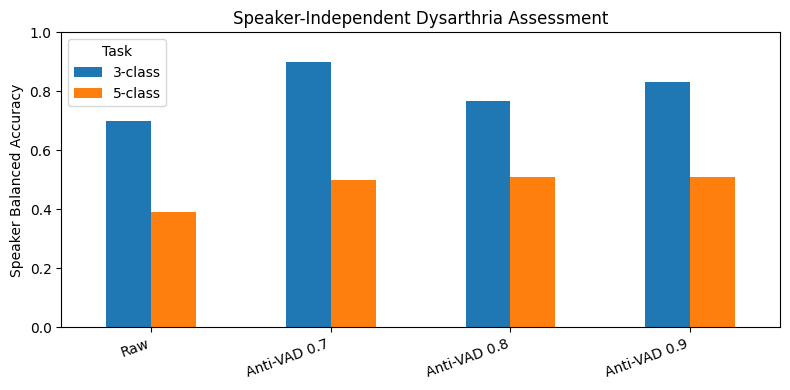

Saved: outputs_uaspeech_silero_rich/fig_main_performance_3class_5class.png


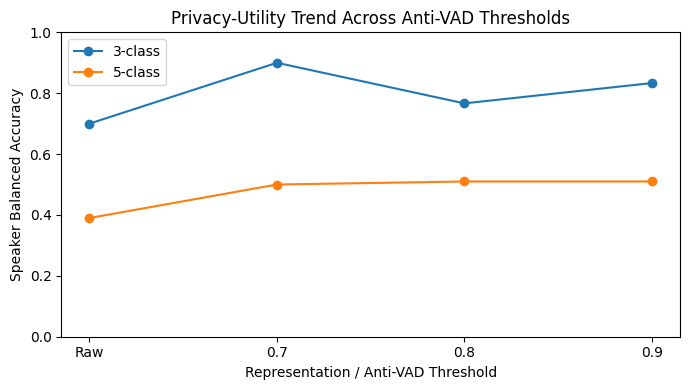

Saved: outputs_uaspeech_silero_rich/fig_privacy_utility_curve.png


In [14]:
plot_main_performance(
    summary_df=results["summary"],
    output_dir=config.output_dir
)

plot_privacy_utility_curve(
    summary_df=results["summary"],
    output_dir=config.output_dir
)

In [13]:
# balanced_summary = pd.read_csv(
#     os.path.join(
#         config.output_dir,
#         "balanced_control_sensitivity_summary_speakers.csv"
#     )
# )

# plot_balanced_sensitivity(
#     balanced_summary_df=balanced_summary,
#     output_dir=config.output_dir
# )

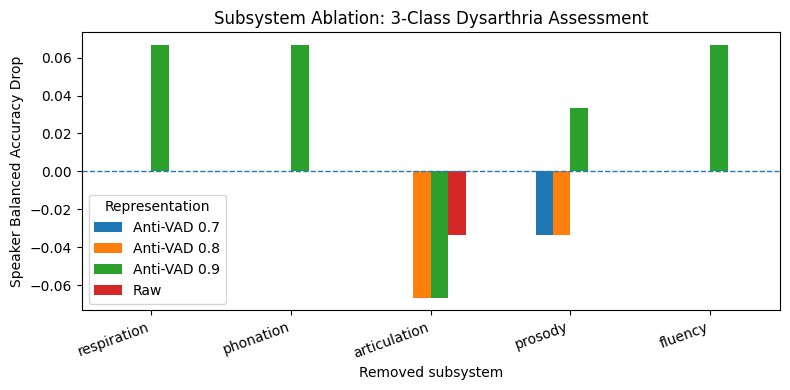

Saved: outputs_uaspeech_silero_rich/fig_subsystem_ablation_3class.png


In [15]:
def plot_subsystem_ablation(ablation_df, output_dir, task="3class_clustered"):
    """
    Plot speaker balanced accuracy drop after removing each subsystem.
    Uses 3-class by default.
    """

    df = ablation_df[
        (ablation_df["task"] == task) &
        (ablation_df["ablation"] != "all_features")
    ].copy()

    label_map = {
        "raw": "Raw",
        "silero_antivad_0.7": "Anti-VAD 0.7",
        "silero_antivad_0.8": "Anti-VAD 0.8",
        "silero_antivad_0.9": "Anti-VAD 0.9",
    }

    df["representation_label"] = df["representation"].map(label_map)

    pivot = df.pivot(
        index="removed_subsystem",
        columns="representation_label",
        values="speaker_balanced_accuracy_drop"
    )

    subsystem_order = [
        "respiration",
        "phonation",
        "articulation",
        "prosody",
        "fluency",
    ]

    pivot = pivot.loc[subsystem_order]

    ax = pivot.plot(kind="bar", figsize=(8, 4))

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.ylabel("Speaker Balanced Accuracy Drop")
    plt.xlabel("Removed subsystem")
    plt.title("Subsystem Ablation: 3-Class Dysarthria Assessment")
    plt.xticks(rotation=20, ha="right")
    plt.legend(title="Representation")

    savefig(os.path.join(output_dir, "fig_subsystem_ablation_3class.png"))


ablation_df = pd.read_csv(
    os.path.join(config.output_dir, "subsystem_ablation_results.csv")
)

plot_subsystem_ablation(
    ablation_df=ablation_df,
    output_dir=config.output_dir,
    task="3class_clustered"
)

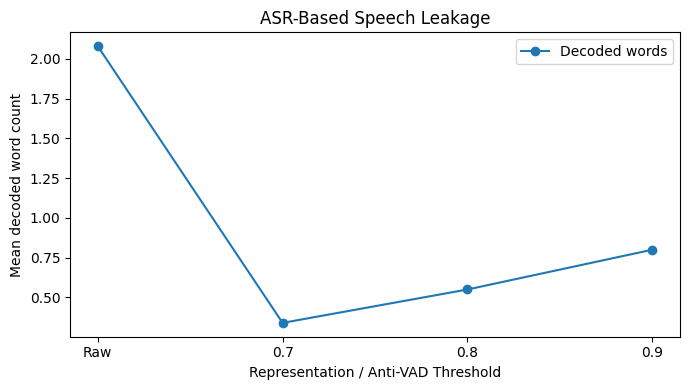

Saved: outputs_uaspeech_silero_rich/fig_asr_speech_leakage.png


In [ ]:
# def plot_asr_leakage(asr_summary, output_dir):
#     """
#     Plot decoded word count as speech leakage proxy.
#     """

#     df = asr_summary.copy()

#     rep_order = ["raw", "silero_antivad_0.7", "silero_antivad_0.8", "silero_antivad_0.9"]
#     rep_labels = ["Raw", "0.7", "0.8", "0.9"]

#     rows = []

#     for rep, label in zip(rep_order, rep_labels):
#         temp = df[df["representation"] == rep]
#         rows.append({
#             "representation": label,
#             "decoded_word_count": temp["decoded_word_count"].mean(),
#             "decoded_char_count": temp["decoded_char_count"].mean(),
#             "residual_energy_ratio": temp["residual_energy_ratio"].mean(),
#             "zero_fraction": temp["zero_fraction"].mean(),
#         })

#     plot_df = pd.DataFrame(rows)

#     plt.figure(figsize=(7, 4))
#     plt.plot(
#         plot_df["representation"],
#         plot_df["decoded_word_count"],
#         marker="o",
#         label="Decoded words"
#     )

#     plt.ylabel("Mean decoded word count")
#     plt.xlabel("Representation / Anti-VAD Threshold")
#     plt.title("ASR-Based Speech Leakage")
#     plt.legend()

#     savefig(os.path.join(output_dir, "fig_asr_speech_leakage.png"))

#     return plot_df


# asr_plot_df = plot_asr_leakage(
#     asr_summary=asr_summary,
#     output_dir=config.output_dir
# )

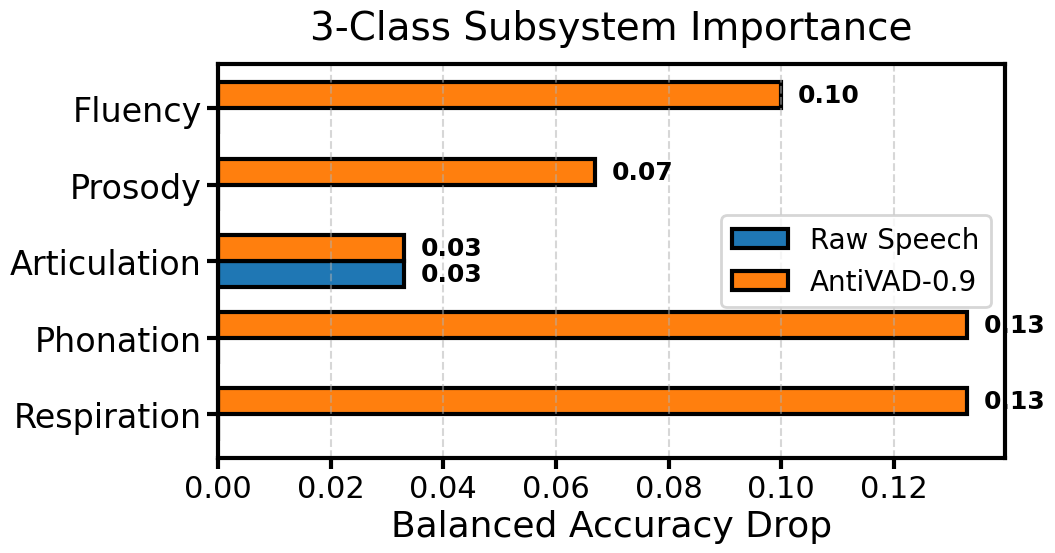

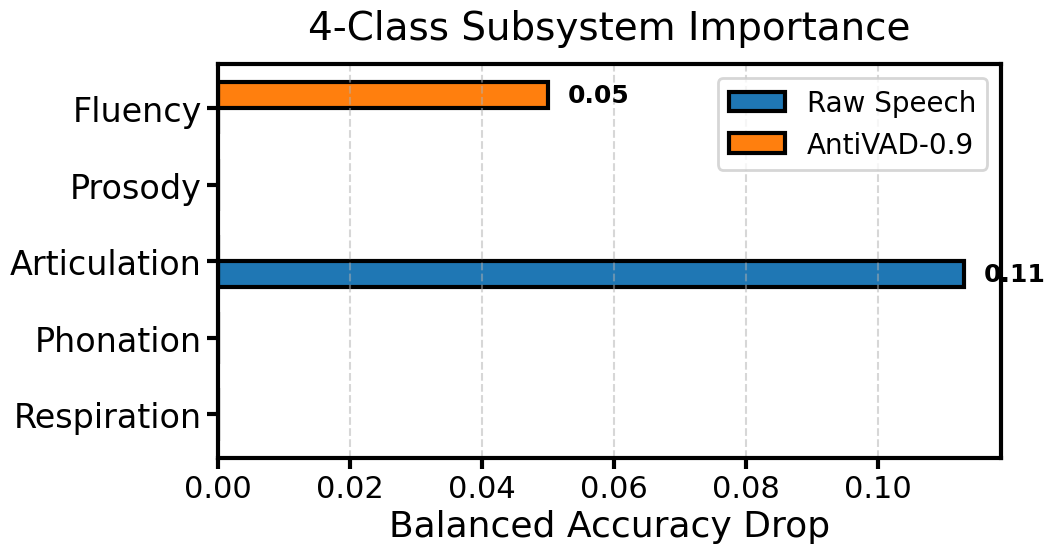

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Style
# ============================================================

plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 26,
    "axes.titlesize": 28,
    "xtick.labelsize": 22,
    "ytick.labelsize": 24,
    "legend.fontsize": 20,
    "axes.linewidth": 3.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ============================================================
# Subsystems
# ============================================================

subsystems = [
    "Respiration",
    "Phonation",
    "Articulation",
    "Prosody",
    "Fluency"
]

# ============================================================
# 3-CLASS
# Raw vs AntiVAD-0.9
# ============================================================

raw_3class = [
    0.00,
    0.00,
    0.033,
    0.00,
    0.00
]

antivad_3class = [
    0.133,
    0.133,
    0.033,
    0.067,
    0.10
]

# ============================================================
# 4-CLASS
# Raw vs AntiVAD-0.9
# ============================================================

raw_4class = [
    0.00,
    0.00,
    0.113,
    0.00,
    0.00
]

antivad_4class = [
    0.00,
    0.00,
    0.00,
    0.00,
    0.05
]

# ============================================================
# Plot function
# ============================================================

def plot_comparison(raw_vals, av_vals, title, out_file):

    fig, ax = plt.subplots(figsize=(11, 6))

    y = np.arange(len(subsystems))
    height = 0.34

    bars1 = ax.barh(
        y - height/2,
        raw_vals,
        height=height,
        linewidth=3,
        edgecolor='black',
        label='Raw Speech'
    )

    bars2 = ax.barh(
        y + height/2,
        av_vals,
        height=height,
        linewidth=3,
        edgecolor='black',
        label='AntiVAD-0.9'
    )

    ax.set_yticks(y)
    ax.set_yticklabels(subsystems)

    ax.set_xlabel("Balanced Accuracy Drop")
    ax.set_title(title, pad=18)

    # thicker spines
    for spine in ax.spines.values():
        spine.set_linewidth(3)

    # thicker ticks
    ax.tick_params(axis='both', width=3, length=8)

    # grid
    ax.grid(
        axis='x',
        linestyle='--',
        linewidth=1.5,
        alpha=0.5
    )

    # legend
    leg = ax.legend(frameon=True)
    leg.get_frame().set_linewidth(2)

    # value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            width = bar.get_width()

            if width > 0:
                ax.text(
                    width + 0.003,
                    bar.get_y() + bar.get_height()/2,
                    f"{width:.2f}",
                    va='center',
                    fontsize=18,
                    fontweight='bold'
                )

    plt.tight_layout()

    plt.savefig(out_file, dpi=400, bbox_inches='tight')
    plt.savefig(out_file.replace(".png", ".pdf"),
                bbox_inches='tight')

    plt.show()


# ============================================================
# Generate plots
# ============================================================

plot_comparison(
    raw_3class,
    antivad_3class,
    "3-Class Subsystem Importance",
    "3class_subsystem_importance.png"
)

plot_comparison(
    raw_4class,
    antivad_4class,
    "4-Class Subsystem Importance",
    "4class_subsystem_importance.png"
)